Feature Engineering

Housing dataset

Check list:
1. handle missing value
2. handle categorical value
3. Scale the features
4. remove outliers
5. feature selection
6. PCA

In [ ]:
import pandas as pd
def load_housing_data(HOUSING_PATH):
 return pd.read_csv(HOUSING_PATH)
housing = load_housing_data("housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
import pandas as pd
def load_titanic_data(TITANIC_PATH):
 return pd.read_csv(TITANIC_PATH)
titanic = load_titanic_data("titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Handle missing value

In [5]:
import pandas as pd
import numpy as np
df = pd.read_csv("housing.csv")
print("Original Housing DataFrame:")
print(df.head())
print("\nMissing values in each column:")
print(df.isnull().sum())

Original Housing DataFrame:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Missing values in each column:
longitude      

In [ ]:
df_dropped_rows = df.dropna()
print("\nDataFrame after dropping rows with missing values:")
print(df_dropped_rows.head())


DataFrame after dropping rows with missing values:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [7]:
df_mean = df.copy()
num_cols = df_mean.select_dtypes(include=np.number).columns
for col in num_cols:
    df_mean[col].fillna(df_mean[col].mean(), inplace=True)
print("\nDataFrame after imputing numerical columns with mean:")
print(df_mean.head())


DataFrame after imputing numerical columns with mean:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


C:\Users\prani\AppData\Local\Temp\ipykernel_15432\4154238190.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_mean[col].fillna(df_mean[col].mean(), inplace=True)


In [8]:
df_mode = df_mean.copy()
cat_cols = df_mode.select_dtypes(include='object').columns
for col in cat_cols:
    df_mode[col].fillna(df_mode[col].mode()[0], inplace=True)
print("\nDataFrame after imputing categorical columns with mode:")
print(df_mode.head())


DataFrame after imputing categorical columns with mode:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


C:\Users\prani\AppData\Local\Temp\ipykernel_15432\4031063087.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_mode.select_dtypes(include='object').columns
C:\Users\prani\AppData\Local\Temp\ipykernel_15432\4031063087.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when d

Handle categorical value

In [9]:
df = pd.read_csv("titanic.csv")
print("Original Dataset:")
print(df.head())

Original Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

In [10]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print("\nAfter filling missing categorical values:")
print(df.head())


After filling missing categorical values:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare    Cabin Embarked  
0      0         A/5 21171   7.2500  B96 B98        S  
1      0          PC 17599  71.2833      C85        C  
2      0  STON/O2. 3101282   7.9250  B96 B98        S  
3      0            113803  53.1000     C123        S

C:\Users\prani\AppData\Local\Temp\ipykernel_15432\2737072668.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [13]:
label_encoder = LabelEncoder()
if 'Sex' in df.columns:
    df['Sex'] = label_encoder.fit_transform(df['Sex'])
print("\nDataFrame after Label Encoding for 'Sex':\n", df.head())


DataFrame after Label Encoding for 'Sex':
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare    Cabin Embarked  
0         A/5 21171   7.2500  B96 B98        S  
1          PC 17599  71.2833      C85        C  
2  STON/O2. 3101282   7.9250  B96 B98        S  
3            113803  53.1000     C123        S  
4      

In [14]:
if 'Embarked' in df.columns:
    preprocessor = ColumnTransformer(
        transformers=[('onehot', OneHotEncoder(), ['Embarked'])],
        remainder='passthrough')
    transformed_data = preprocessor.fit_transform(df)
    feature_names = preprocessor.get_feature_names_out()
    df_encoded = pd.DataFrame(transformed_data, columns=feature_names)
    print("\nDataFrame after OneHot Encoding:")
    print(df_encoded.head())


DataFrame after OneHot Encoding:
  onehot__Embarked_C onehot__Embarked_Q onehot__Embarked_S  \
0                0.0                0.0                1.0   
1                1.0                0.0                0.0   
2                0.0                0.0                1.0   
3                0.0                0.0                1.0   
4                0.0                0.0                1.0   

  remainder__PassengerId remainder__Survived remainder__Pclass  \
0                      1                   0                 3   
1                      2                   1                 1   
2                      3                   1                 3   
3                      4                   1                 1   
4                      5                   0                 3   

                                     remainder__Name remainder__Sex  \
0                            Braund, Mr. Owen Harris              1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  

Scale the features

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

In [46]:
np.random.seed(42)
df = pd.read_csv("./housing.csv")
num_cols = df.select_dtypes(include=np.number).columns
df_num = df[num_cols]
df_num = df_num.fillna(df_num.mean())
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
maxabs_scaler = MaxAbsScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df_num), columns=num_cols)
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df_num), columns=num_cols)
df_robust = pd.DataFrame(robust_scaler.fit_transform(df_num), columns=num_cols)
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df_num), columns=num_cols)
df_log = np.log1p(df_num)
print("\nStandard Scaled Data:\n", df_standard.head())
print("\nMinMax Scaled Data:\n", df_minmax.head())
print("\nRobust Scaled Data:\n", df_robust.head())
print("\nMaxAbs Scaled Data:\n", df_maxabs.head())
print("\nLog Transformed Data:\n", df_log.head())


Standard Scaled Data:
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.327835  1.052548            0.982143    -0.804819       -0.975228   
1  -1.322844  1.043185           -0.607019     2.045890        1.355088   
2  -1.332827  1.038503            1.856182    -0.535746       -0.829732   
3  -1.337818  1.038503            1.856182    -0.624215       -0.722399   
4  -1.337818  1.038503            1.856182    -0.462404       -0.615066   

   population  households  median_income  median_house_value  
0   -0.974429   -0.977033       2.344766            2.129631  
1    0.861439    1.669961       2.332238            1.314156  
2   -0.820777   -0.843637       1.782699            1.258693  
3   -0.766028   -0.733781       0.932968            1.165100  
4   -0.759847   -0.629157      -0.012881            1.172900  

MinMax Scaled Data:
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   0.211155  0.567481            0.784314     0.0

c:\Users\prani\OneDrive\Desktop\fod\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [ ]:
Remove outliers

Original Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

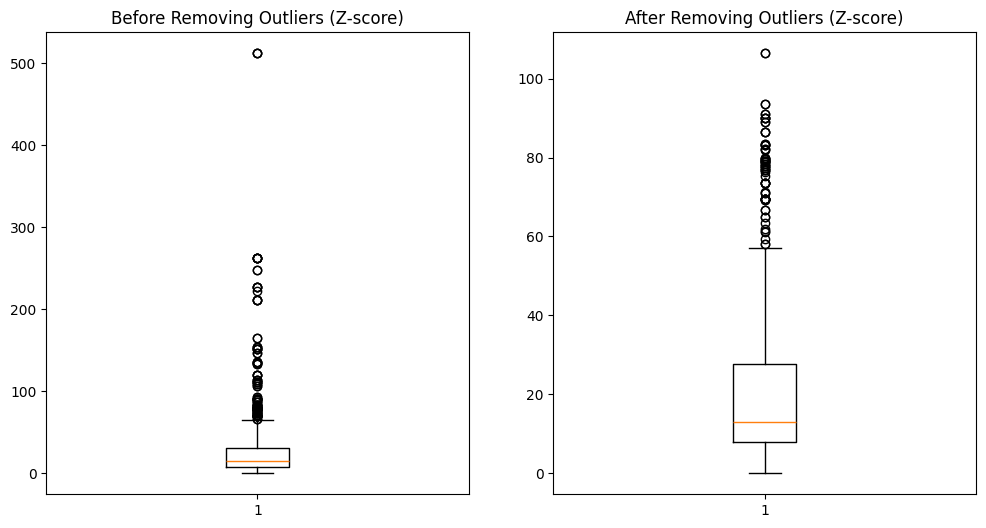


Data after removing outliers (Z-score method):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      

In [52]:
import matplotlib.pyplot as plt
df = pd.read_csv("titanic.csv")
print("Original Dataset:")
print(df.head())
column_name = 'Fare'
data_reshaped = df[[column_name]].values
scaler = StandardScaler()
z_scores = scaler.fit_transform(data_reshaped)
threshold = 1.5
df_filtered_z = df[np.abs(z_scores).flatten() < threshold]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.boxplot(df[column_name].dropna())
ax1.set_title("Before Removing Outliers (Z-score)")
ax2.boxplot(df_filtered_z[column_name].dropna())
ax2.set_title("After Removing Outliers (Z-score)")
plt.show()
print("\nData after removing outliers (Z-score method):")
print(df_filtered_z.head())

Iterations to remove outliers: 2


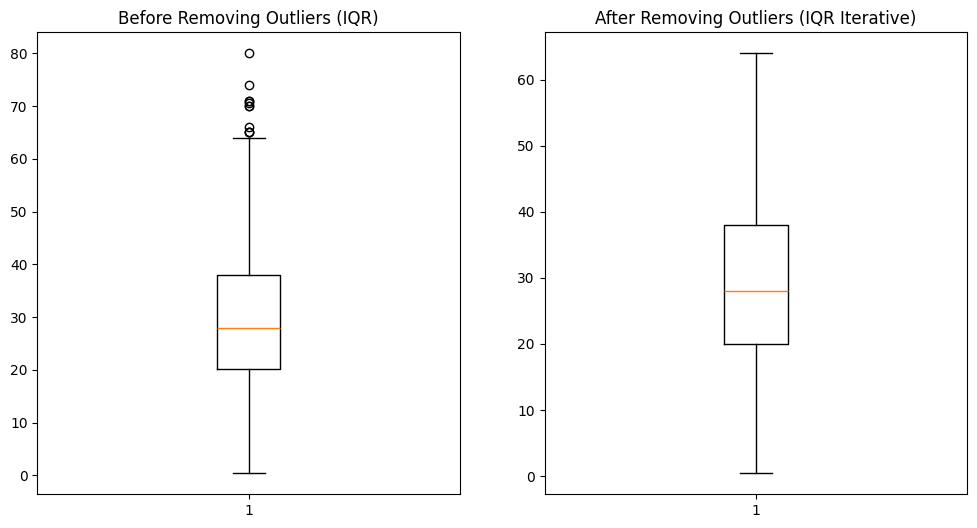


Data after removing outliers (IQR method):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0   

In [ ]:
column_name = 'Age' 
df_filtered_iqr = df.copy()
iteration = 0
while True:
    Q1 = df_filtered_iqr[column_name].quantile(0.25)
    Q3 = df_filtered_iqr[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    prev_shape = df_filtered_iqr.shape[0]
    df_filtered_iqr = df_filtered_iqr[(df_filtered_iqr[column_name] >= lower_bound) &
                                      (df_filtered_iqr[column_name] <= upper_bound)]
    iteration += 1
    
    
    if df_filtered_iqr.shape[0] == prev_shape:
        break

print(f"Iterations to remove outliers: {iteration}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.boxplot(df[column_name].dropna())
ax1.set_title("Before Removing Outliers (IQR)")
ax2.boxplot(df_filtered_iqr[column_name].dropna())
ax2.set_title("After Removing Outliers (IQR Iterative)")
plt.show()

print("\nData after removing outliers (IQR method):")
print(df_filtered_iqr.head())


Feature Selection

Titanic Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

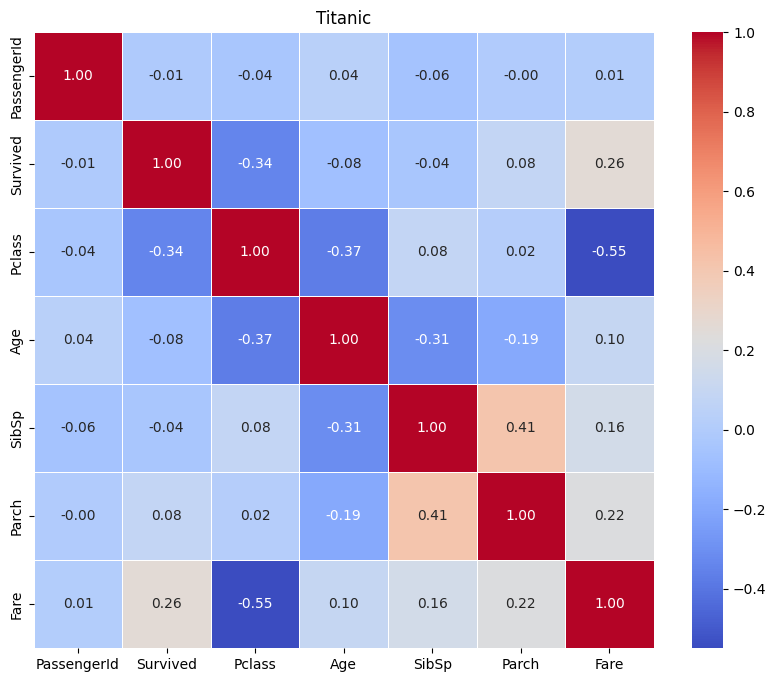


Highly correlated columns:
[]


In [42]:
titanic_new = pd.read_csv("titanic.csv")
print("Titanic Dataset:")
print(titanic_new.head())
titanic_numeric = titanic_new.select_dtypes(include=np.number)
corr_matrix = titanic_numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title("Titanic")
plt.show()
corr_threshold = 0.9
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns
           if any(abs(upper_triangle[column]) > corr_threshold)]
print("\nHighly correlated columns:")
print(to_drop)


PCA

In [47]:
import pandas as pd
df = pd.read_csv("housing.csv")  # Replace with actual dataset path
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
from sklearn.preprocessing import StandardScaler
numerical_features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['median_house_value'], errors='ignore')  # Drop target if applicable
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_features)

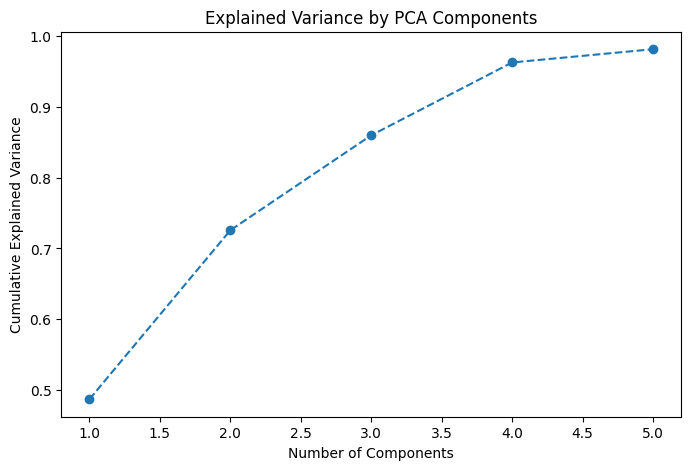

In [49]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")  
scaled_data = imputer.fit_transform(scaled_data)
from sklearn.decomposition import PCA
pca = PCA(n_components=5)  
pca_features = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_features, columns=[f'PC{i+1}' for i in range(5)])
import matplotlib.pyplot as plt
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance.cumsum(), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()

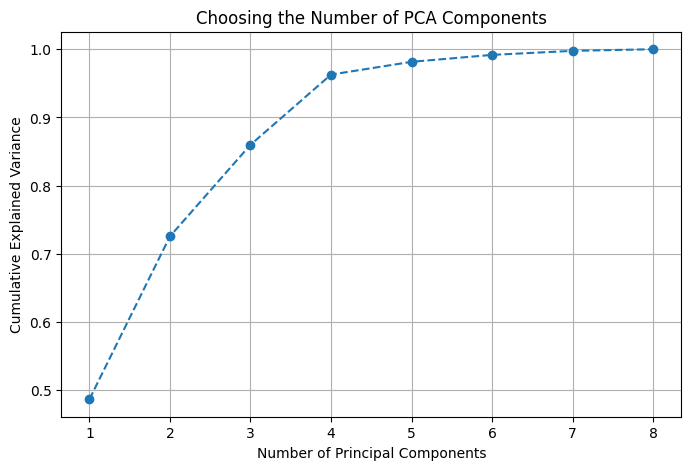

In [50]:
from sklearn.decomposition import PCA
import numpy as np
pca = PCA()
pca.fit(scaled_data)
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing the Number of PCA Components")
plt.grid()
plt.show()